In [185]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [186]:
df = pd.read_csv("credit_risk_dataset.csv.zip")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [187]:
df.shape

(32581, 12)

In [188]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [189]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [190]:
df['loan_status'].unique()

array([1, 0])

In [191]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

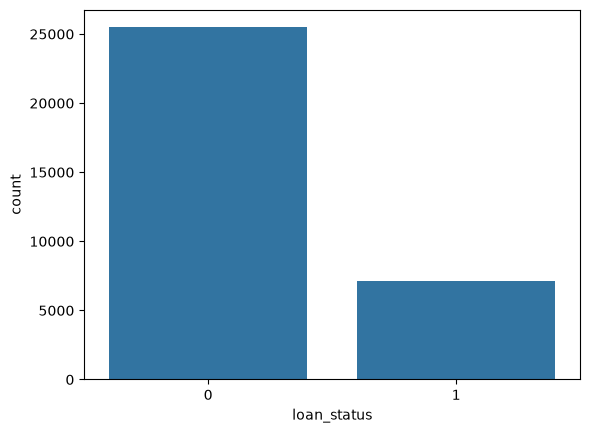

In [192]:
sns.countplot(x='loan_status',data=df)

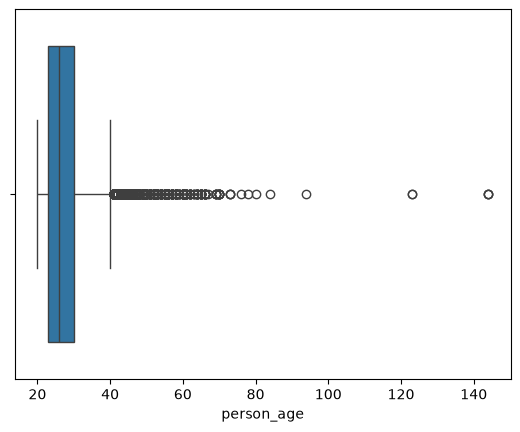

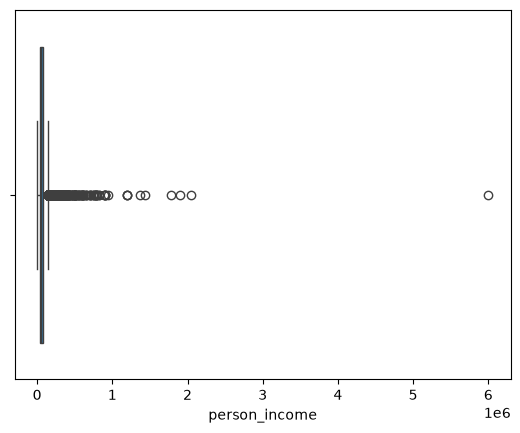

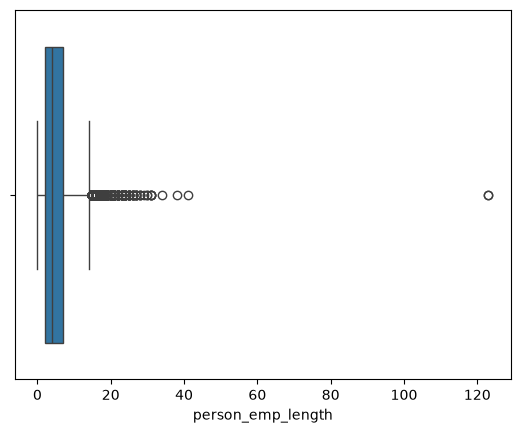

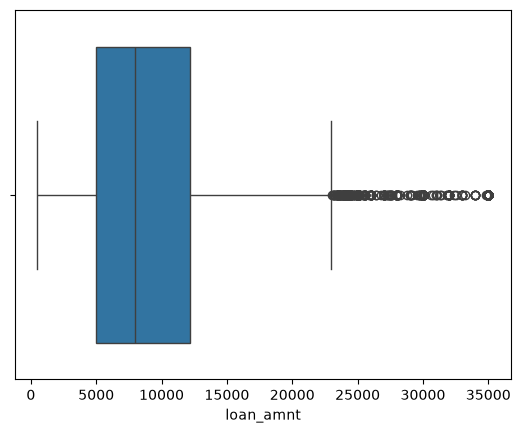

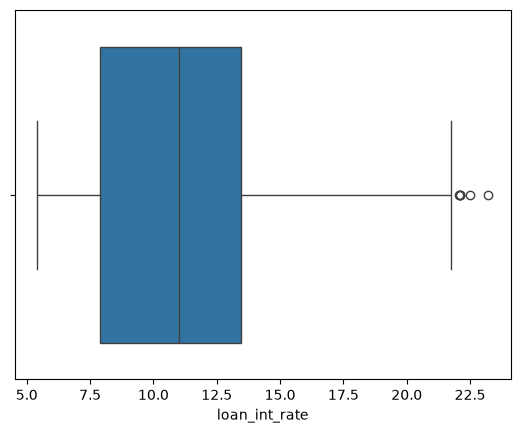

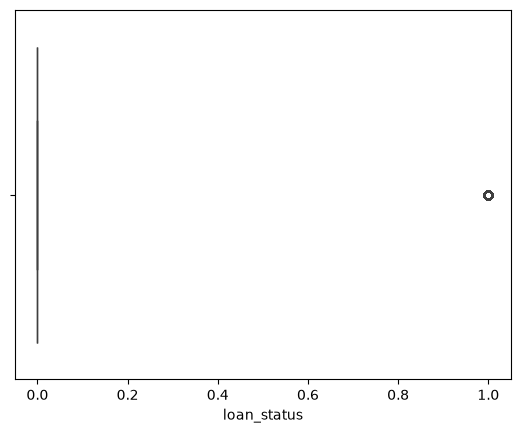

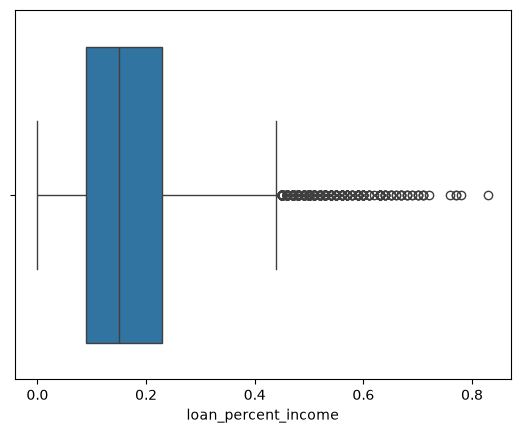

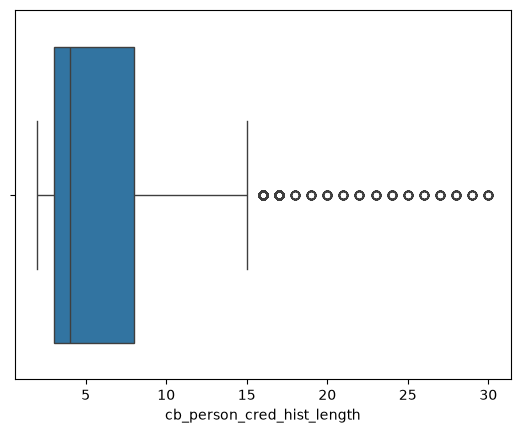

In [193]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols
for  i in numerical_cols:
    sns.boxplot(x=df[i])
    plt.show()

   

In [194]:
(df['person_age'] >100).sum()

np.int64(5)

In [195]:
(df['person_emp_length'] >60).sum()

np.int64(2)

In [196]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


<Axes: >

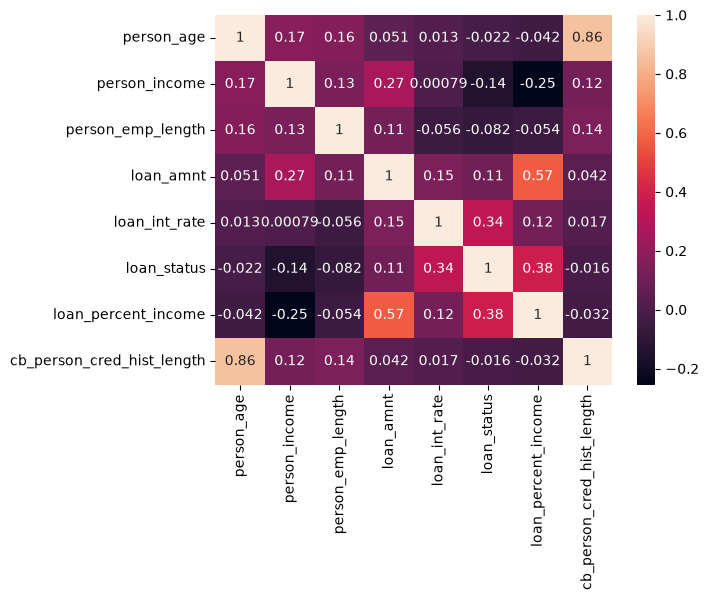

In [197]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [198]:
# Data cleaning starts from here

df_copy = df.copy()

print(f"Original rows: {df_copy.shape[0]}")

# Remove duplicate rows
df_copy.drop_duplicates(inplace=True)

print(f"Rows after removing duplicates: {df_copy.shape[0]}")

# Keep age between 18 and 100
df_copy = df_copy[
    (df_copy['person_age'] >= 18) &
    (df_copy['person_age'] <= 100)
]

# Employment length should not be greater than age
df_copy = df_copy[
    df_copy['person_emp_length'] <= df_copy['person_age']
]

# Loan amount should be greater than 0
df_copy = df_copy[
    df_copy['loan_amnt'] > 0
]

print(f"Rows after cleaning: {df_copy.shape[0]}")

df_copy

Original rows: 32581
Rows after removing duplicates: 32416
Rows after cleaning: 31522


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [199]:
x = df_copy.drop('loan_status',axis=1)
y = df_copy['loan_status']

In [200]:
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [201]:
numerical_cols = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']
categorical_cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

In [202]:
neg,pos= np.bincount(y_train)
scale_weight = neg/pos

In [203]:
#logistic regression inpute numeric col, impute one hot incoding
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder


In [204]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        #pipeline is for numerical column
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),


        #pipeline is for categorcal column
        ('cat',Pipeline([ 
            ('imputer',SimpleImputer(strategy="constant",fill_value="missing")),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ]
)

In [205]:
#xgboost pipeline:impute numerica only ,impute + one hot encoding
preprocessor_xg = ColumnTransformer(
    transformers=[
        #pipeline is for numerical column
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
            
        ]), numerical_cols),


        #pipeline is for categorcal column
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy="constant",fill_value="missing")),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ]
)

In [206]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,classification_report,precision_recall_curve
from sklearn.metrics import confusion_matrix

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    confusion_matrix
)

def evaluate_model(model_name, model, x_test, y_test,threshold=None):
    
    # Predictions
    y_pred = model.predict(x_test)
    y_pred_prob = model.predict_proba(x_test)[:, 1]

    if threshold:
        y_pred = (y_pred_prob > threshold).astype(int)
    else:
        y_pred = model.predict(x_test)
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)

    # Print metrics
    print(f"\n{model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Classification report
    class_report = classification_report(y_test, y_pred)

    print("\nClassification Report:")
    print(class_report)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d")

    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("Actual Values")
    plt.xlabel("Predicted Values")
    plt.show()

    # Precision-Recall curve
    precision_values, recall_values, thresholds = precision_recall_curve(
        y_test,
        y_pred_prob
    )

    plt.plot(recall_values, precision_values)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.show()

In [207]:
from sklearn.model_selection import StratifiedKFold,cross_validate
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring = {'roc_auc':'roc_auc','accuracy':'accuracy','precision':'precision','recall':'recall','f1':'f1'}

In [208]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_cr_Pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])
lr_cr_Pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [209]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

scale_weights = (y_train == 0).sum() / (y_train == 1).sum()

xgb_cr_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),

    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_weights,
        random_state=42,
        n_jobs=-1
    ))
])
xgb_cr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [210]:
for cv_name, pipe in [("logistic regression", lr_cr_Pipeline),
                      ("xgboost", xgb_cr_pipeline)]:
    cv_result = cross_validate(
        pipe,
        x_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    cv_result
    print(f"ROC-AUC:{cv_result['test_roc_auc'].mean()}")
    print(f"ROC-AUC:{cv_result['test_accuracy'].mean()}")
    print(f"precision:{cv_result['test_precision'].mean()}")
    print(f"F1:{cv_result['test_f1'].mean()}")

    

ROC-AUC:0.8705112830525306
ROC-AUC:0.8115949542892269
precision:0.5448226008889892
F1:0.6408013995933108
ROC-AUC:0.9470945968526715
ROC-AUC:0.917952083139717
precision:0.8190795992296656
F1:0.8073360762846882


In [211]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight="balanced"))
])
baseline_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [212]:
xg_model = Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(learning_rate=0.1,scale_pos_weights=scale_weights,random_state=42))
])
xg_model.fit(x_train,y_train)

c:\Users\HP\OneDrive\Desktop\deep learning\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:45:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "scale_pos_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['person_age','person_income','person_home_ownership',..., 'loan_percent_income','cb_person_default_on_file', 'cb_person_cred_hist_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [213]:
from scipy.stats import randint, uniform

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth": randint(3, 9),
    "classifier__learning_rate": uniform(0.01, 0.49),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0, 5)
}


In [214]:
from sklearn.model_selection import RandomizedSearchCV

In [215]:
print(RandomizedSearchCV)

<class 'sklearn.model_selection._search.RandomizedSearchCV'>


In [216]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\HP\OneDrive\Desktop\deep learning\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:46:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "scale_pos_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': <scipy.stats....001792CE34A40>, 'classifier__gamma': <scipy.stats....001792CE34A10>, 'classifier__learning_rate': <scipy.stats....001792FF8F800>, 'classifier__max_depth': <scipy.stats....0017928A85340>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are consid


Baseline Logistic Model
Accuracy: 0.8193
Precision: 0.5580
Recall: 0.7871
F1 Score: 0.6531
ROC-AUC: 0.8751

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



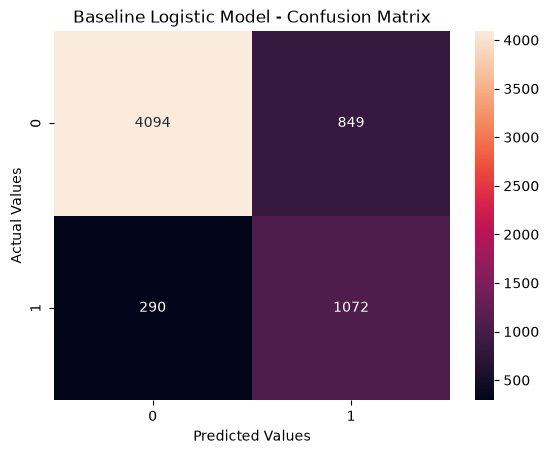

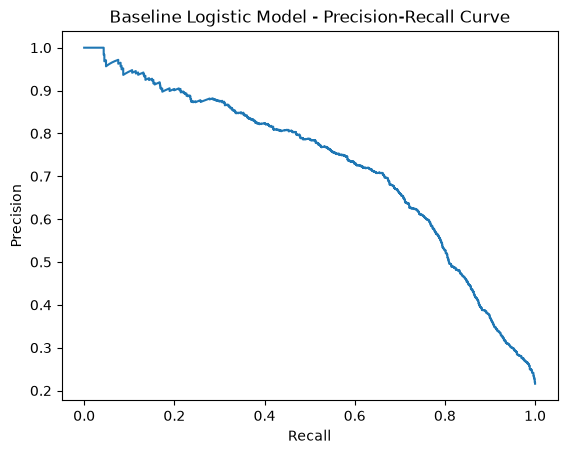

In [217]:
evaluate_model(
    "Baseline Logistic Model",
    baseline_model,
    x_test,
    y_test
)


xgbooxt
Accuracy: 0.9369
Precision: 0.9744
Recall: 0.7269
F1 Score: 0.8326
ROC-AUC: 0.9484

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.97      0.73      0.83      1362

    accuracy                           0.94      6305
   macro avg       0.95      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



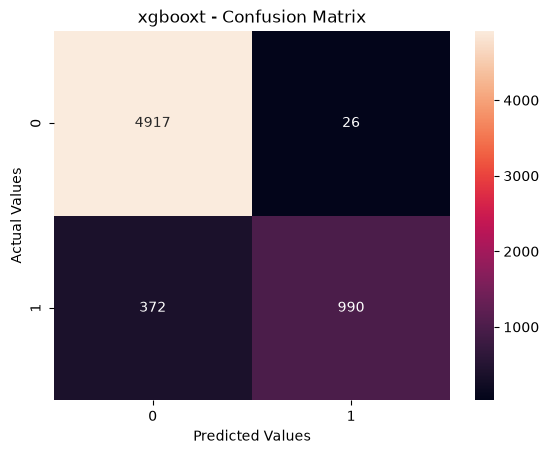

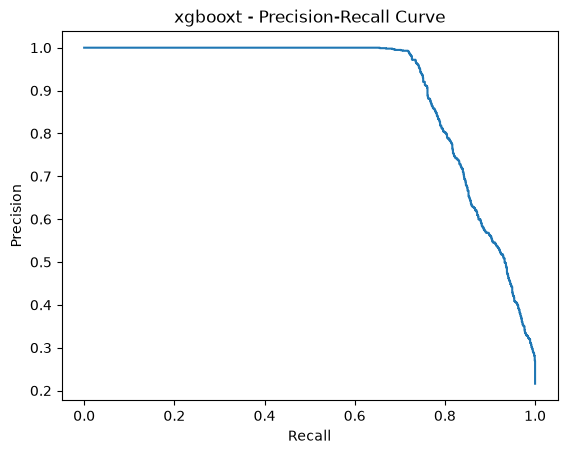

In [218]:
evaluate_model("xgbooxt",xg_model,x_test,y_test)

Best F1 Score: 0.8369565212487625
Best Threshold: 0.46085197

xgboost
Accuracy: 0.9380
Precision: 0.9718
Recall: 0.7342
F1 Score: 0.8365
ROC-AUC: 0.9484

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.97      0.73      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.95      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



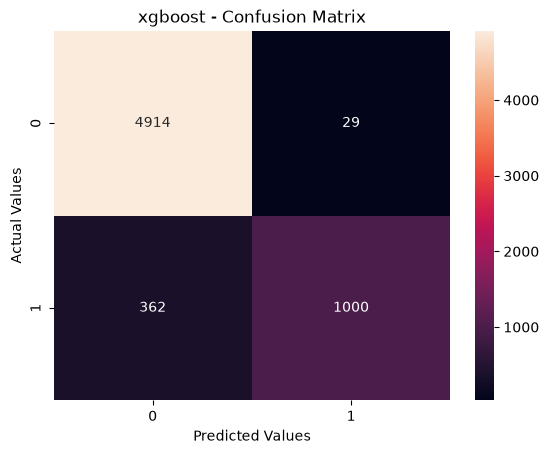

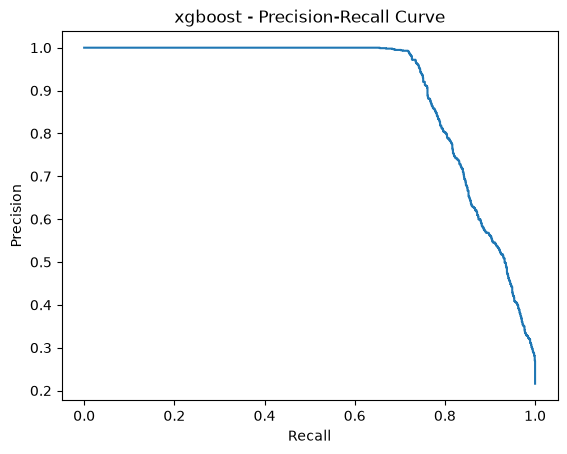

In [219]:
from sklearn.metrics import precision_recall_curve
import numpy as np

prob = xg_model.predict_proba(x_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, prob)

f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

best_index = np.argmax(f1[:-1])

best_threshold = thresholds[best_index]

print("Best F1 Score:", f1[best_index])
print("Best Threshold:", best_threshold)

evaluate_model("xgboost",xg_model,x_test,y_test,best_threshold)

In [220]:
from sklearn.calibration import CalibratedClassifierCV
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(x_train, y_train)

c:\Users\HP\OneDrive\Desktop\deep learning\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:46:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "scale_pos_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\HP\OneDrive\Desktop\deep learning\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:46:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "scale_pos_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\HP\OneDrive\Desktop\deep learning\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:46:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "scale_pos_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\HP\OneDrive\Desktop\deep learning\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:46:54] WARNING: C:\actions-runner\_work\xgboost\xgbo

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...001792FFDEA20>, <

In [221]:
uncalibrated = xg_model.predict_proba(x_test)[:,1]
calibrated = calibrated_model.predict_proba(x_test)[:,1]

In [222]:
from sklearn.calibration import calibration_curve
actual_uncal,predicted_uncal = calibration_curve(y_test,uncalibrated,n_bins=10)

In [223]:
actual_cal,predicted_cal = calibration_curve(y_test,uncalibrated,n_bins=10)

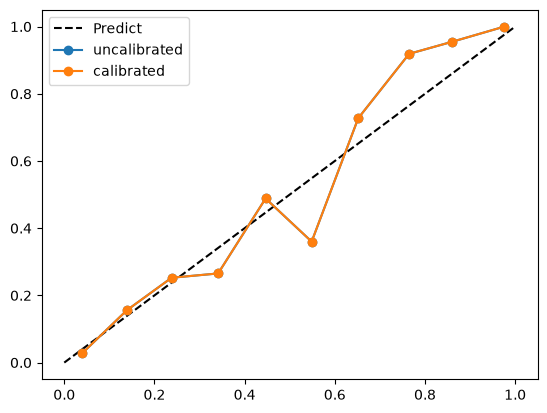

In [224]:
plt.plot([0, 1], [0, 1], "k--", label="Predict")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label = "uncalibrated"
)

plt.plot(
    predicted_uncal,
    actual_cal,
    "o-",
    label = "calibrated"
)
plt.legend()


In [225]:
import shap 

In [226]:
xg_classifier = xg_model.named_steps['classifier']
x_test_transformed = xg_model.named_steps['preprocessor'].transform(x_test)

features_names= xg_model.named_steps['preprocessor'].get_feature_names_out()

In [227]:
x_test_df = pd.DataFrame(x_test_transformed,columns=features_names)


In [228]:
explainer = shap.TreeExplainer(xg_classifier)

In [229]:
shap_value = explainer.shap_values(x_test_df)

In [230]:
shap_value[5]

array([-3.28885764e-02, -8.35403860e-01,  1.00894375e-02, -5.75883240e-02,
       -4.96892869e-01, -3.37956578e-01,  3.17309275e-02, -1.75563470e-02,
       -5.50907629e-04,  8.56501311e-02, -3.07865202e-01, -4.78852428e-02,
       -7.80576956e-04, -4.03195545e-02, -7.33925924e-02, -3.05955880e-03,
        1.70225590e-01,  1.14533730e-01, -2.14382783e-01,  7.23976269e-02,
       -6.62302002e-02, -1.97246820e-02, -1.50258103e-02, -9.43258684e-03,
       -2.15839483e-02,  0.00000000e+00], dtype=float32)

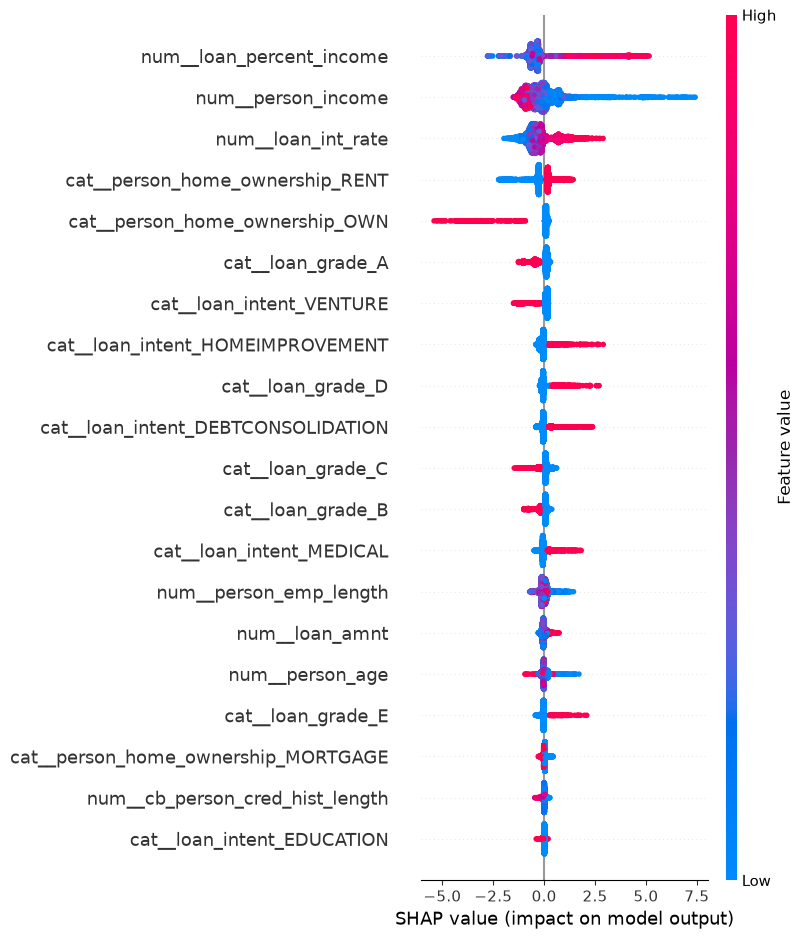

In [231]:

shap.summary_plot(shap_value,x_test_df)

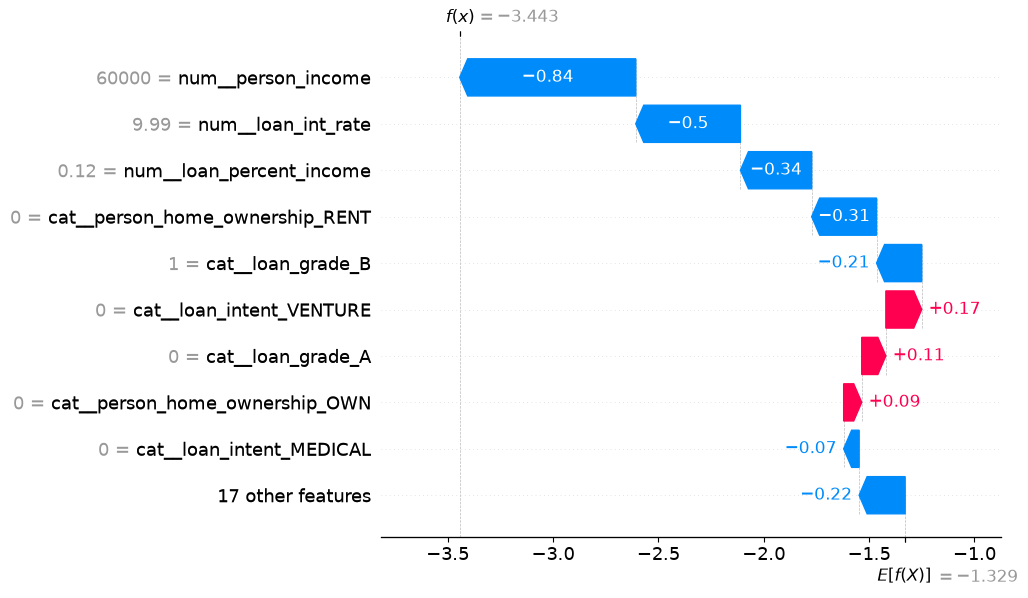

In [232]:
row_index = 5
shap.plots.waterfall(
    shap.Explanation(
        values = shap_value[row_index],
        base_values=explainer.expected_value,
        data=x_test_df.iloc[row_index],
        feature_names=features_names
    )
)

In [233]:
y_pred = random_search.predict(x_test)

In [234]:
result_df = x_test.copy()
result_df['actual'] = y_test
result_df['predicted']=y_pred

In [235]:
result_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
14455,24,30000,OWN,1.0,MEDICAL,E,15000,15.68,0.50,N,3,1,1
8701,23,60000,MORTGAGE,6.0,EDUCATION,C,25600,NaN,0.43,N,4,0,0
19804,29,18000,RENT,2.0,EDUCATION,C,3600,15.27,0.20,N,6,1,1
27252,32,130000,MORTGAGE,7.0,MEDICAL,B,13000,12.69,0.10,N,8,0,0
5610,23,45288,MORTGAGE,7.0,DEBTCONSOLIDATION,B,20500,9.25,0.45,N,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11661,21,75000,MORTGAGE,5.0,PERSONAL,C,20000,13.11,0.27,Y,2,0,0
27837,29,265000,MORTGAGE,2.0,PERSONAL,B,25000,11.26,0.09,N,10,0,0
17192,25,48996,MORTGAGE,8.0,MEDICAL,B,5000,9.88,0.10,N,2,1,0
26858,27,115000,MORTGAGE,11.0,MEDICAL,A,8000,7.51,0.07,N,7,0,0


In [236]:
false_positive = result_df[(result_df['actual']==0) &(result_df['predicted']==1)]
false_negative = result_df[(result_df['actual']==1) &(result_df['predicted']==0)]

In [237]:
print(f"false positive:{len(false_positive)}")
print(f"false negative:{len(false_negative)}")

false positive:47
false negative:344


In [238]:
import joblib
joblib.dump(calibrated_model,"credit_risk_model.pkl")

['credit_risk_model.pkl']

In [239]:
joblib.dump(best_threshold,"best_threshold.pkl")

['best_threshold.pkl']

In [240]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Get probabilities
calibrated_proba = calibrated_model.predict_proba(x_test)[:, 1]

# Precision, recall and thresholds
precision, recall, thresholds = precision_recall_curve(
    y_test,
    calibrated_proba
)

# Calculate F1 score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

# Find best threshold
best_index = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_index]

print("Best threshold:", best_threshold)
print("Best F1 score:", f1_scores[best_index])

Best threshold: 0.5653569236435045
Best F1 score: 0.8450704220434568
